<a href="https://colab.research.google.com/github/shrishtib07/SHRISHTI/blob/main/phase1eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

# Display all columns
pd.set_option('display.max_columns', None)

# Style
sns.set(style="whitegrid")

In [3]:
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/orange_juice_withmissing.csv"

df = pd.read_csv(url)

df.head()

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1.0,1.75,1.99,0.00,0.0,0.0,0.0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1.0
1,CH,239,1.0,1.75,1.99,0.00,0.3,0.0,1.0,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1.0
2,CH,245,1.0,1.86,2.09,0.17,0.0,0.0,0.0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1.0
3,MM,227,1.0,1.69,1.69,0.00,0.0,0.0,0.0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1.0
4,CH,228,7.0,1.69,1.69,0.00,0.0,0.0,0.0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Purchase        1070 non-null   object 
 1   WeekofPurchase  1070 non-null   int64  
 2   StoreID         1069 non-null   float64
 3   PriceCH         1069 non-null   float64
 4   PriceMM         1066 non-null   float64
 5   DiscCH          1068 non-null   float64
 6   DiscMM          1066 non-null   float64
 7   SpecialCH       1068 non-null   float64
 8   SpecialMM       1065 non-null   float64
 9   LoyalCH         1065 non-null   float64
 10  SalePriceMM     1065 non-null   float64
 11  SalePriceCH     1069 non-null   float64
 12  PriceDiff       1069 non-null   float64
 13  Store7          1070 non-null   object 
 14  PctDiscMM       1065 non-null   float64
 15  PctDiscCH       1068 non-null   float64
 16  ListPriceDiff   1070 non-null   float64
 17  STORE           1068 non-null   f

In [5]:
df.shape

(1070, 18)

In [6]:
df.columns

Index(['Purchase', 'WeekofPurchase', 'StoreID', 'PriceCH', 'PriceMM', 'DiscCH',
       'DiscMM', 'SpecialCH', 'SpecialMM', 'LoyalCH', 'SalePriceMM',
       'SalePriceCH', 'PriceDiff', 'Store7', 'PctDiscMM', 'PctDiscCH',
       'ListPriceDiff', 'STORE'],
      dtype='object')

In [7]:
df.describe(include='all')

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
count,1070,1070.000000,1069.000000,1069.000000,1066.000000,1068.000000,1066.000000,1068.000000,1065.000000,1065.000000,1065.000000,1069.000000,1069.000000,1070,1065.000000,1068.000000,1070.000000,1068.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN
top,CH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN
freq,653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,714,NaN,NaN,NaN,NaN
mean,NaN,254.381308,3.956969,1.867428,2.085038,0.051957,0.123415,0.147004,0.162441,0.565203,1.961934,1.815519,0.146324,NaN,0.059388,0.027318,0.217991,1.628277
std,NaN,15.558286,2.308189,0.102017,0.134429,0.117563,0.214126,0.354276,0.369028,0.308070,0.252510,0.143444,0.271638,NaN,0.101841,0.062281,0.107535,1.430497
min,NaN,227.000000,1.000000,1.690000,1.690000,0.000000,0.000000,0.000000,0.000000,0.000011,1.190000,1.390000,-0.670000,NaN,0.000000,0.000000,0.000000,0.000000
25%,NaN,240.000000,2.000000,1.790000,1.990000,0.000000,0.000000,0.000000,0.000000,0.320000,1.690000,1.750000,0.000000,NaN,0.000000,0.000000,0.140000,0.000000
50%,NaN,257.000000,3.000000,1.860000,2.090000,0.000000,0.000000,0.000000,0.000000,0.600000,2.090000,1.860000,0.230000,NaN,0.000000,0.000000,0.240000,2.000000
75%,NaN,268.000000,7.000000,1.990000,2.180000,0.000000,0.230000,0.000000,0.000000,0.850578,2.130000,1.890000,0.320000,NaN,0.112676,0.000000,0.300000,3.000000


In [8]:
print("Mean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nMode")
print(df.mode().iloc[0])

print("\nVariance")
print(df.var(numeric_only=True))

print("\nStandard Deviation")
print(df.std(numeric_only=True))

Mean
WeekofPurchase    254.381308
StoreID             3.956969
PriceCH             1.867428
PriceMM             2.085038
DiscCH              0.051957
DiscMM              0.123415
SpecialCH           0.147004
SpecialMM           0.162441
LoyalCH             0.565203
SalePriceMM         1.961934
SalePriceCH         1.815519
PriceDiff           0.146324
PctDiscMM           0.059388
PctDiscCH           0.027318
ListPriceDiff       0.217991
STORE               1.628277
dtype: float64

Median
WeekofPurchase    257.00
StoreID             3.00
PriceCH             1.86
PriceMM             2.09
DiscCH              0.00
DiscMM              0.00
SpecialCH           0.00
SpecialMM           0.00
LoyalCH             0.60
SalePriceMM         2.09
SalePriceCH         1.86
PriceDiff           0.23
PctDiscMM           0.00
PctDiscCH           0.00
ListPriceDiff       0.24
STORE               2.00
dtype: float64

Mode
Purchase            CH
WeekofPurchase     274
StoreID            7.0
PriceCH           

In [9]:
df.isnull().sum()

,0
Purchase,0
WeekofPurchase,0
StoreID,1
PriceCH,1
PriceMM,4
DiscCH,2
DiscMM,4
SpecialCH,2
SpecialMM,5
LoyalCH,5


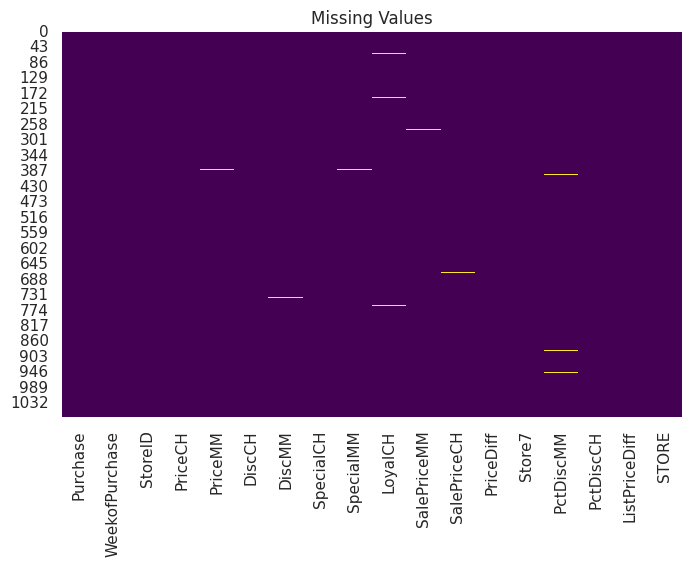

In [10]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values")
plt.show()

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_989/2579964100.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_989/2579964100.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [13]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_989/2422164989.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [14]:
df.isnull().sum()

,0
Purchase,0
WeekofPurchase,0
StoreID,0
PriceCH,0
PriceMM,0
DiscCH,0
DiscMM,0
SpecialCH,0
SpecialMM,0
LoyalCH,0


In [15]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicates: 25


In [16]:
df.dtypes

,0
Purchase,object
WeekofPurchase,int64
StoreID,float64
PriceCH,float64
PriceMM,float64
DiscCH,float64
DiscMM,float64
SpecialCH,float64
SpecialMM,float64
LoyalCH,float64


In [17]:
df.columns = df.columns.str.strip()

In [18]:
encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

In [19]:
df.head()

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,0,237,1.0,1.75,1.99,0.00,0.0,0.0,0.0,0.500000,1.99,1.75,0.24,0,0.000000,0.000000,0.24,1.0
1,0,239,1.0,1.75,1.99,0.00,0.3,0.0,1.0,0.600000,1.69,1.75,-0.06,0,0.150754,0.000000,0.24,1.0
2,0,245,1.0,1.86,2.09,0.17,0.0,0.0,0.0,0.680000,2.09,1.69,0.40,0,0.000000,0.091398,0.23,1.0
3,1,227,1.0,1.69,1.69,0.00,0.0,0.0,0.0,0.400000,1.69,1.69,0.00,0,0.000000,0.000000,0.00,1.0
4,0,228,7.0,1.69,1.69,0.00,0.0,0.0,0.0,0.956535,1.69,1.69,0.00,1,0.000000,0.000000,0.00,0.0


In [20]:
scaler = StandardScaler()

scaled_columns = numeric_cols

df[scaled_columns] = scaler.fit_transform(df[scaled_columns])

df.head()

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,0,-1.119792,-1.276396,-1.152176,-0.709072,-0.439579,-0.570037,-0.406195,-0.439229,-0.212866,0.101429,-0.469573,0.343091,0,-0.576556,-0.43622,0.207033,-0.448549
1,0,-0.991306,-1.276396,-1.152176,-0.709072,-0.439579,0.847820,-0.406195,2.276715,0.110769,-1.100759,-0.469573,-0.769436,0,0.922790,-0.43622,0.207033,-0.448549
2,0,-0.605849,-1.276396,-0.074443,0.038411,1.026372,-0.570037,-0.406195,-0.439229,0.369677,0.502158,-0.892471,0.936439,0,-0.576556,1.05273,0.114497,-0.448549
3,1,-1.762220,-1.276396,-1.740030,-2.951520,-0.439579,-0.570037,-0.406195,-0.439229,-0.536501,-1.100759,-0.892471,-0.546930,0,-0.576556,-0.43622,-2.013838,-0.448549
4,0,-1.697977,1.332145,-1.740030,-2.951520,-0.439579,-0.570037,-0.406195,-0.439229,1.264640,-1.100759,-0.892471,-0.546930,1,-0.576556,-0.43622,-2.013838,-1.149196


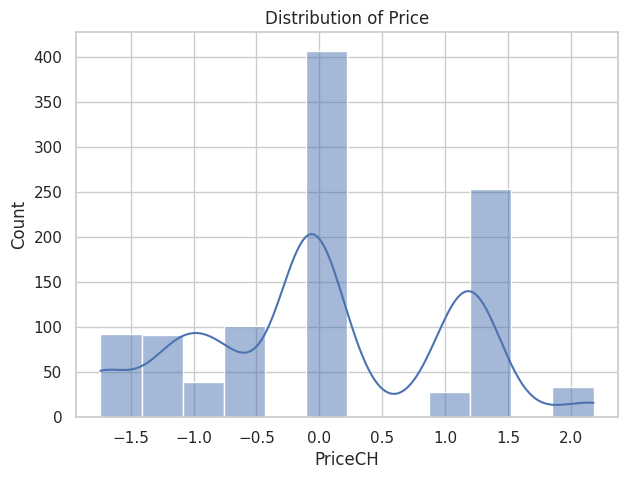

In [22]:
plt.figure(figsize=(7,5))
sns.histplot(df['PriceCH'], kde=True)
plt.title("Distribution of Price")
plt.show()

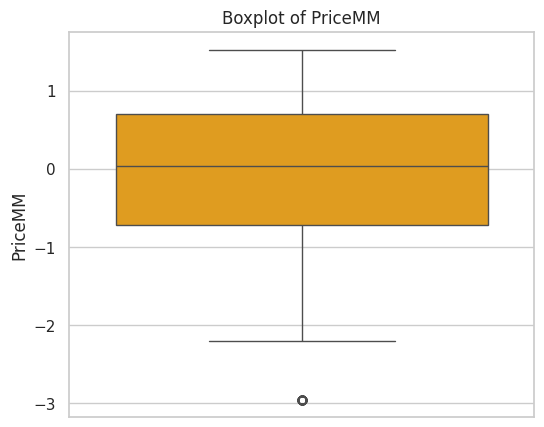

In [24]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df['PriceMM'], color='orange')
plt.title("Boxplot of PriceMM")
plt.show()

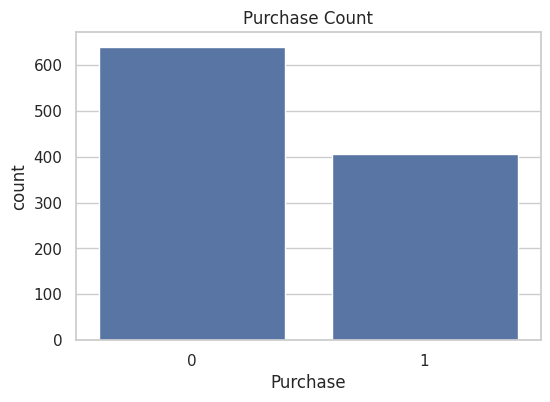

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x='Purchase', data=df)
plt.title("Purchase Count")
plt.show()

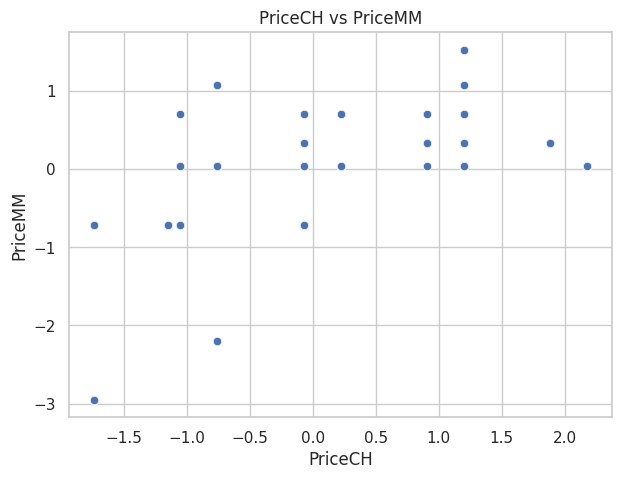

In [26]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='PriceCH', y='PriceMM', data=df)
plt.title("PriceCH vs PriceMM")
plt.show()

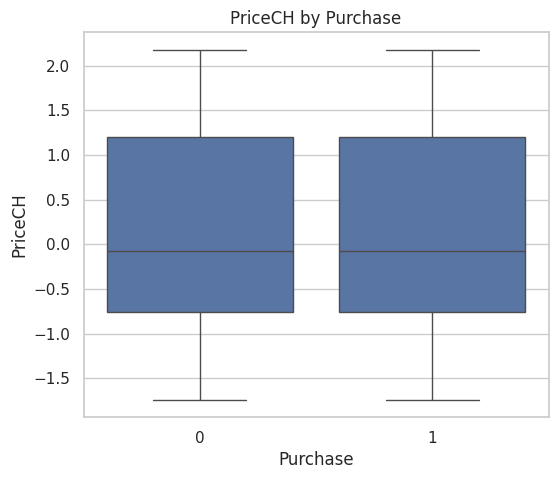

In [27]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Purchase', y='PriceCH', data=df)
plt.title("PriceCH by Purchase")
plt.show()

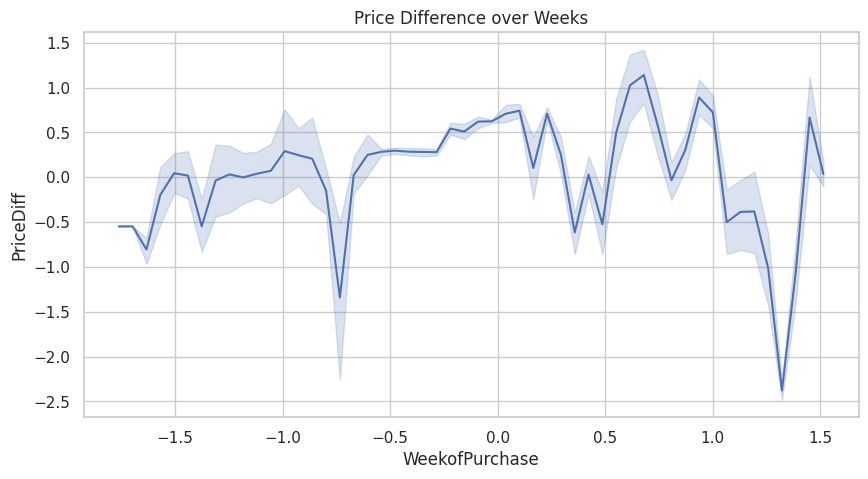

In [28]:
plt.figure(figsize=(10,5))
sns.lineplot(x='WeekofPurchase', y='PriceDiff', data=df)
plt.title("Price Difference over Weeks")
plt.show()

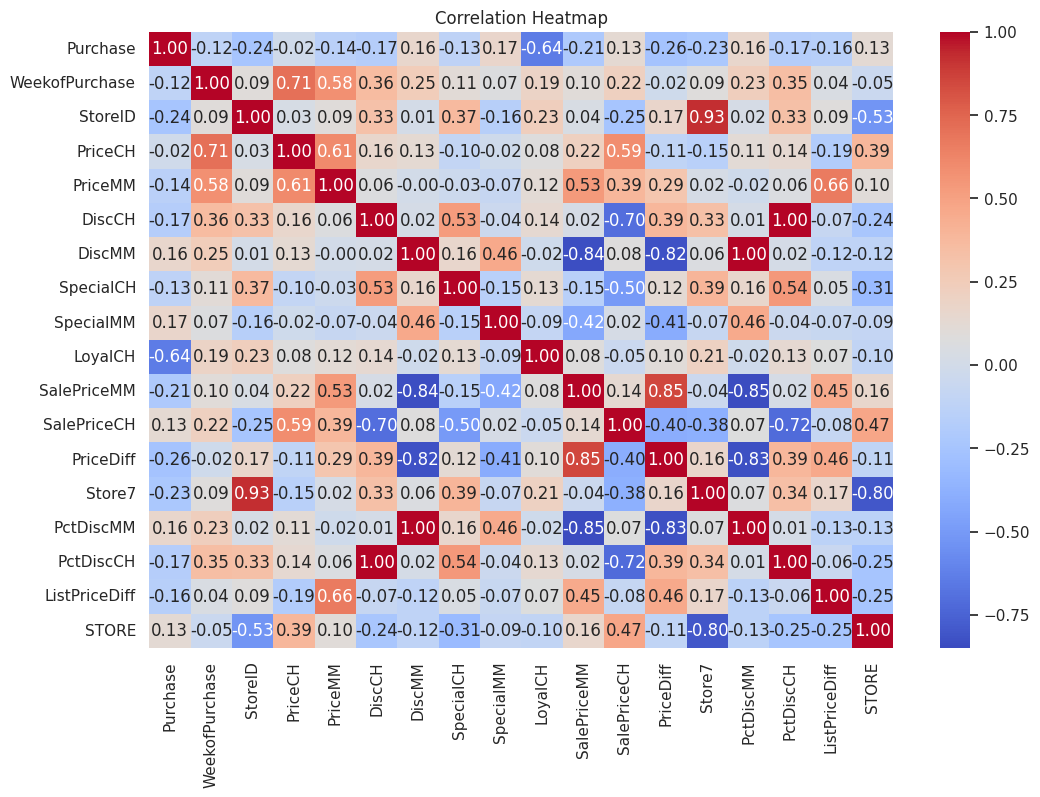

In [29]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

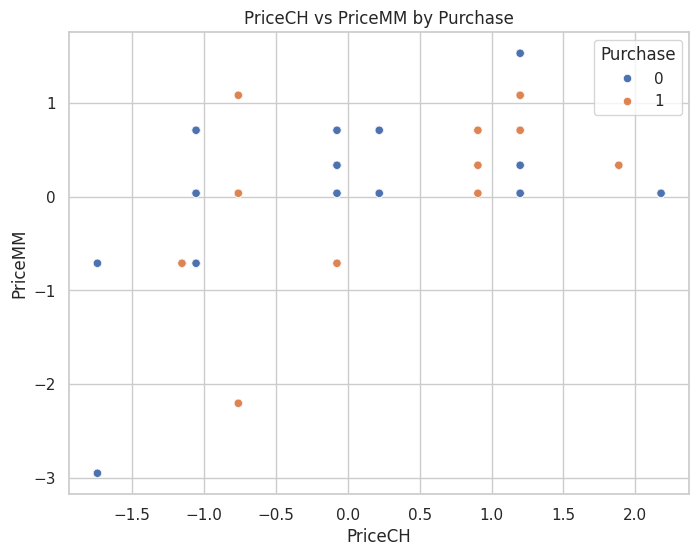

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PriceCH',
    y='PriceMM',
    hue='Purchase',
    data=df
)

plt.title("PriceCH vs PriceMM by Purchase")
plt.show()